GAS TURBINE FAULT DETECTION

In [1]:
#I imported neccessary python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,roc_curve, precision_recall_curve, f1_score)
import warnings
warnings.filterwarnings('ignore')


# I load the Gas Turbine Fault Detection dataset with Pandas
df = pd.read_csv(r"C:\Users\DELL\Downloads\gas_turbine_fault_detection.csv")
df


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temperature (°C),Oil Temperature (°C),Fault
0,924.835708,15650.870645,3464.645167,1.675087,96.347590,2.265294,146.245460,517.611726,90.530958,0
1,893.086785,15780.755598,3190.276340,2.042084,83.288302,2.755950,166.812134,500.196460,136.047350,0
2,932.384427,15016.002075,3401.769251,2.006414,120.358735,2.574244,133.494161,516.272719,124.910039,0
3,976.151493,14623.291065,3443.024901,2.239914,104.689781,2.497101,140.141635,475.731083,123.298231,1
4,888.292331,15229.986071,3448.764050,1.865677,95.080431,2.763689,109.795667,546.737163,119.382239,1
...,...,...,...,...,...,...,...,...,...,...
1381,875.604430,15227.370456,3350.615343,2.476231,86.784442,3.309499,162.299225,487.100258,127.675091,1
1382,1007.865411,14741.785178,3698.033248,2.844594,100.210927,2.572621,174.071561,539.700228,134.785139,0
1383,869.714254,14901.766708,3456.573785,2.834961,88.689328,2.244707,120.214315,499.007960,109.533809,1
1384,937.104769,14897.070285,3605.307337,2.611974,99.327225,2.759177,145.080093,506.625253,123.173626,0


In [2]:
#checking for missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1386 entries, 0 to 1385
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Temperature (°C)              1386 non-null   float64
 1   RPM                           1386 non-null   float64
 2   Torque (Nm)                   1386 non-null   float64
 3   Vibrations (mm/s)             1386 non-null   float64
 4   Power Output (MW)             1386 non-null   float64
 5   Fuel Flow Rate (kg/s)         1386 non-null   float64
 6   Air Pressure (kPa)            1386 non-null   float64
 7   Exhaust Gas Temperature (°C)  1386 non-null   float64
 8   Oil Temperature (°C)          1386 non-null   float64
 9   Fault                         1386 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 108.4 KB


In [3]:
#summary statistics
df.describe()


,Temperature (°C),RPM,Torque (Nm),Vibrations (mm/s),Power Output (MW),Fuel Flow Rate (kg/s),Air Pressure (kPa),Exhaust Gas Temperature (°C),Oil Temperature (°C),Fault
count,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000,1386.000000
mean,901.623932,15022.591497,3494.764285,1.978964,99.497230,2.505591,150.320568,498.865296,120.061923,0.306638
std,49.381498,490.048647,203.828153,0.494025,10.309697,0.316582,19.430192,28.793950,10.005188,0.461264
min,737.936633,13490.243922,2901.772806,0.411648,71.004861,1.349003,93.961769,382.327992,86.244209,0.000000
25%,868.117411,14688.039309,3355.445978,1.658465,92.387182,2.296762,137.688214,479.238499,113.652494,0.000000
50%,901.964879,15016.737353,3490.639925,1.989549,99.378143,2.500537,150.464896,498.865627,119.968056,0.000000
75%,932.692748,15346.057959,3627.482077,2.322288,106.454488,2.724751,163.130104,518.337798,126.570199,1.000000
max,1092.636575,16596.553784,4285.247541,3.556455,135.290552,3.513215,213.155426,587.423276,153.777682,1.000000


In [4]:
#checking for duplicates
df.duplicated().sum()

np.int64(0)

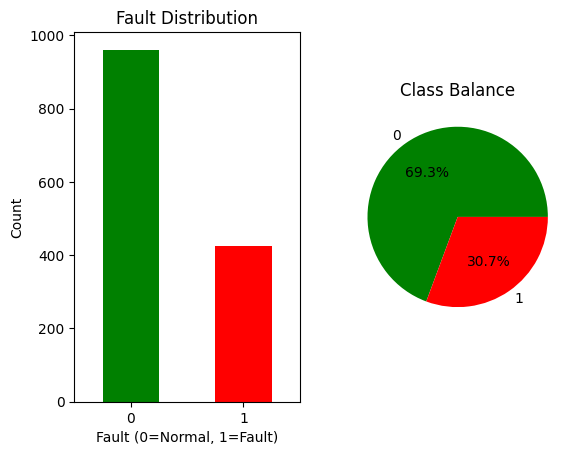

In [5]:
#check class balance visually
plt.subplot(1, 2, 1)
df['Fault'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Fault Distribution')
plt.xlabel('Fault (0=Normal, 1=Fault)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['Fault'].value_counts().plot(kind='pie',autopct='%1.1f%%', colors=['green', 'red'])
plt.title('Class Balance')
plt.show()

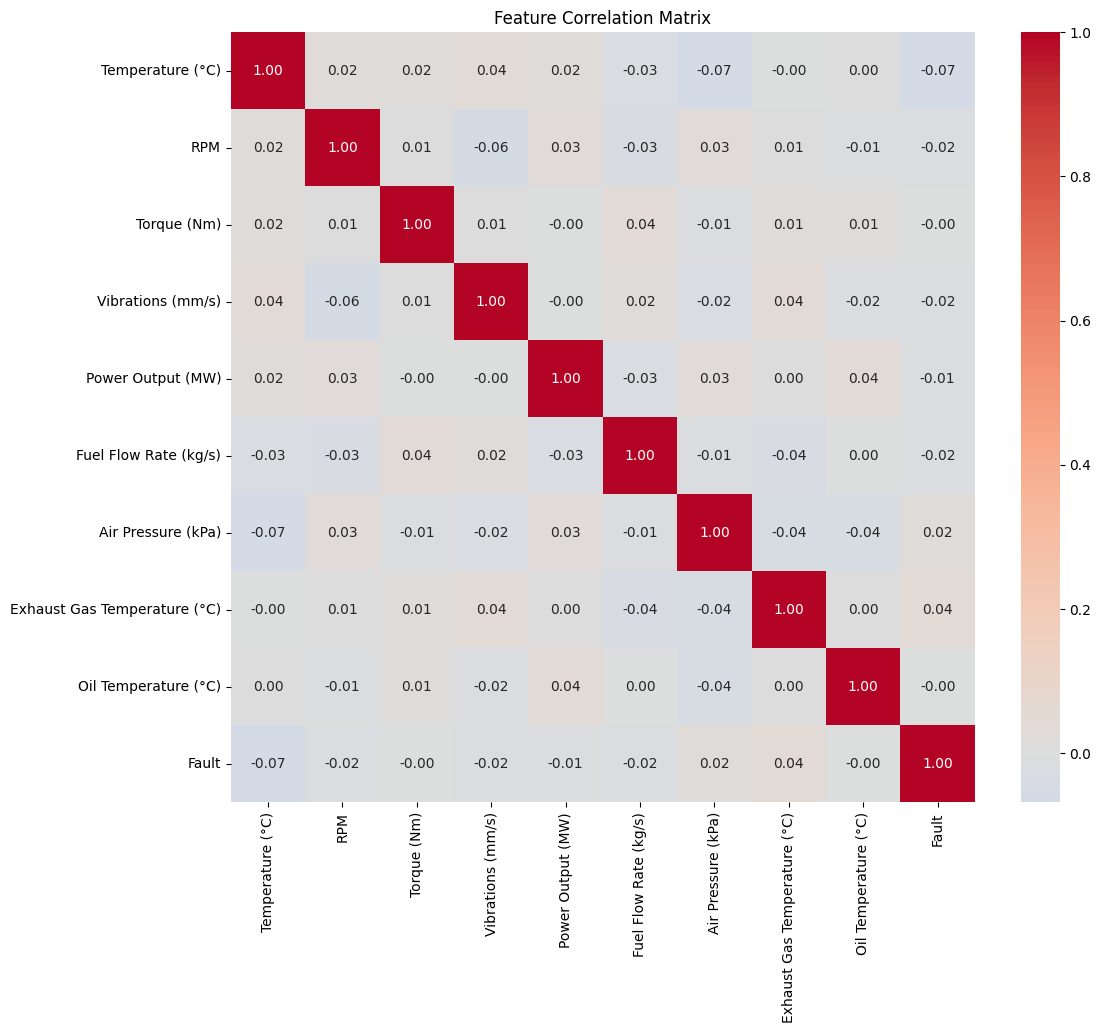

Correlation with Fault:
 Fault                           1.000000
Exhaust Gas Temperature (°C)    0.044570
Air Pressure (kPa)              0.019300
Torque (Nm)                    -0.002820
Oil Temperature (°C)           -0.003800
Power Output (MW)              -0.013284
Fuel Flow Rate (kg/s)          -0.016047
RPM                            -0.018466
Vibrations (mm/s)              -0.019193
Temperature (°C)               -0.068022
Name: Fault, dtype: float64


In [6]:
#Correlation Analysis
#Correlation matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

#Correlation with target
corr_with_target = corr_matrix['Fault'].sort_values(ascending=False)
print("Correlation with Fault:\n", corr_with_target)

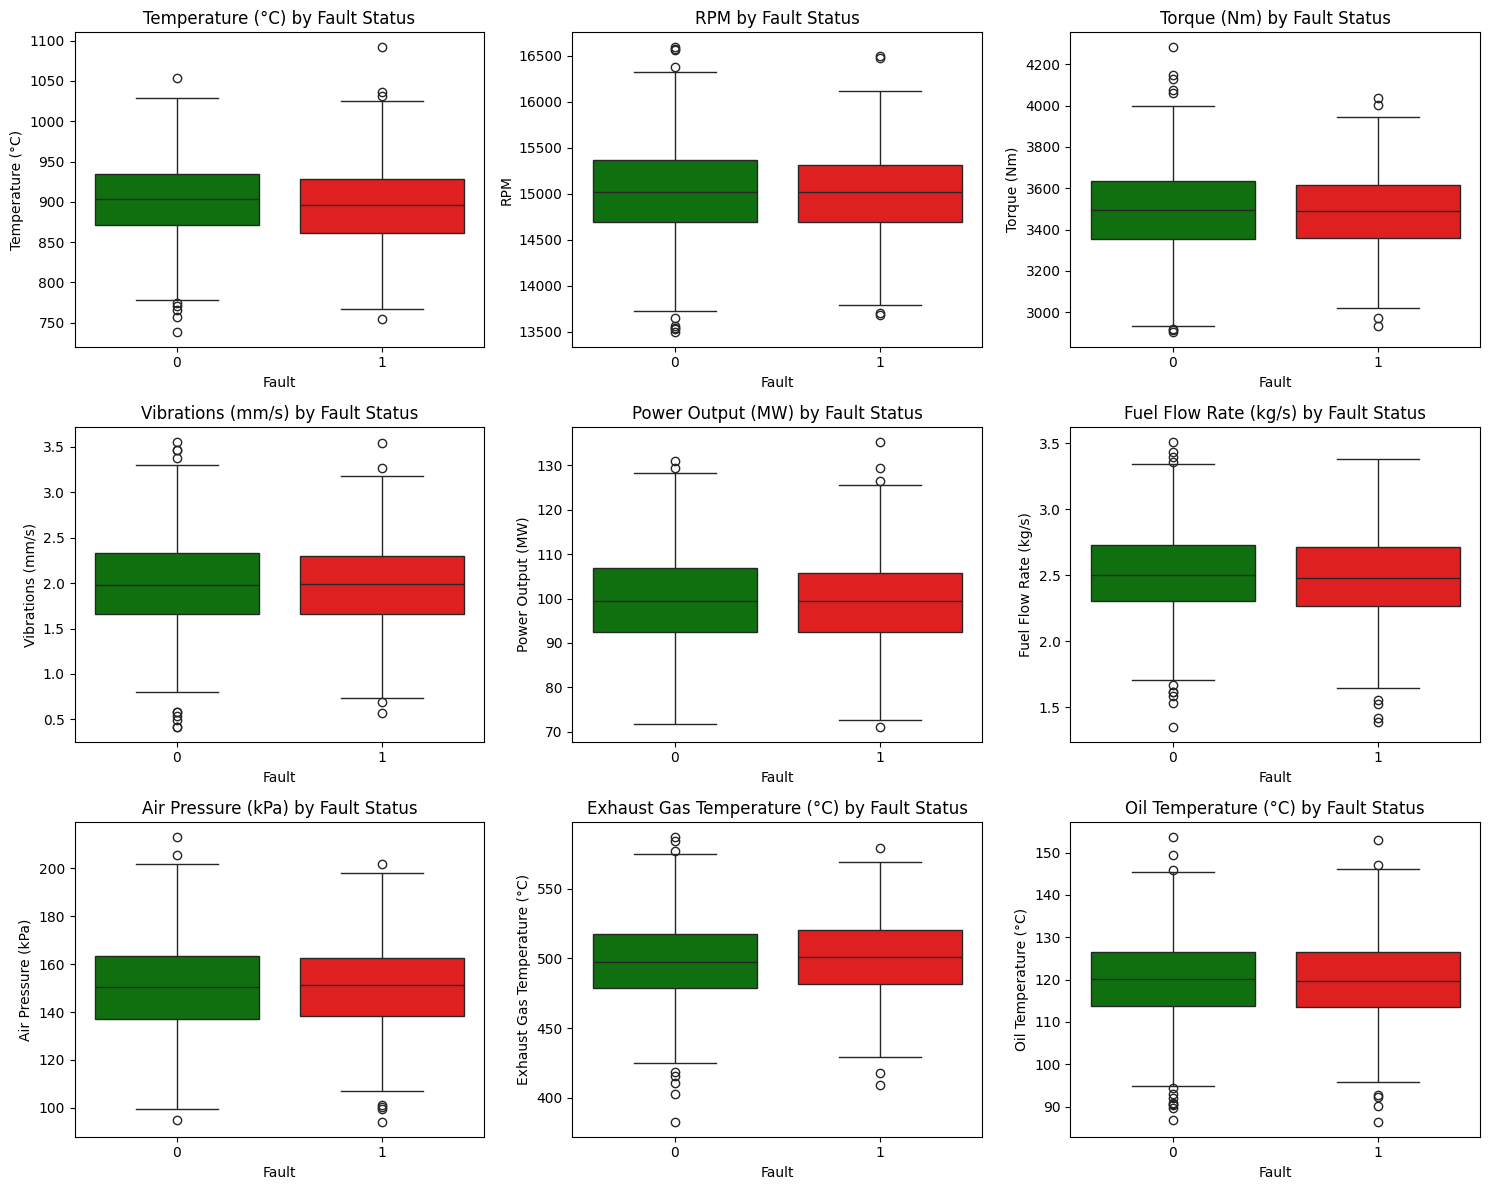

In [7]:
#Box plots for each feature
features = [col for col in df.columns if col != 'Fault']
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Fault', y=feature, data=df, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{feature} by Fault Status')

plt.tight_layout()
plt.show()

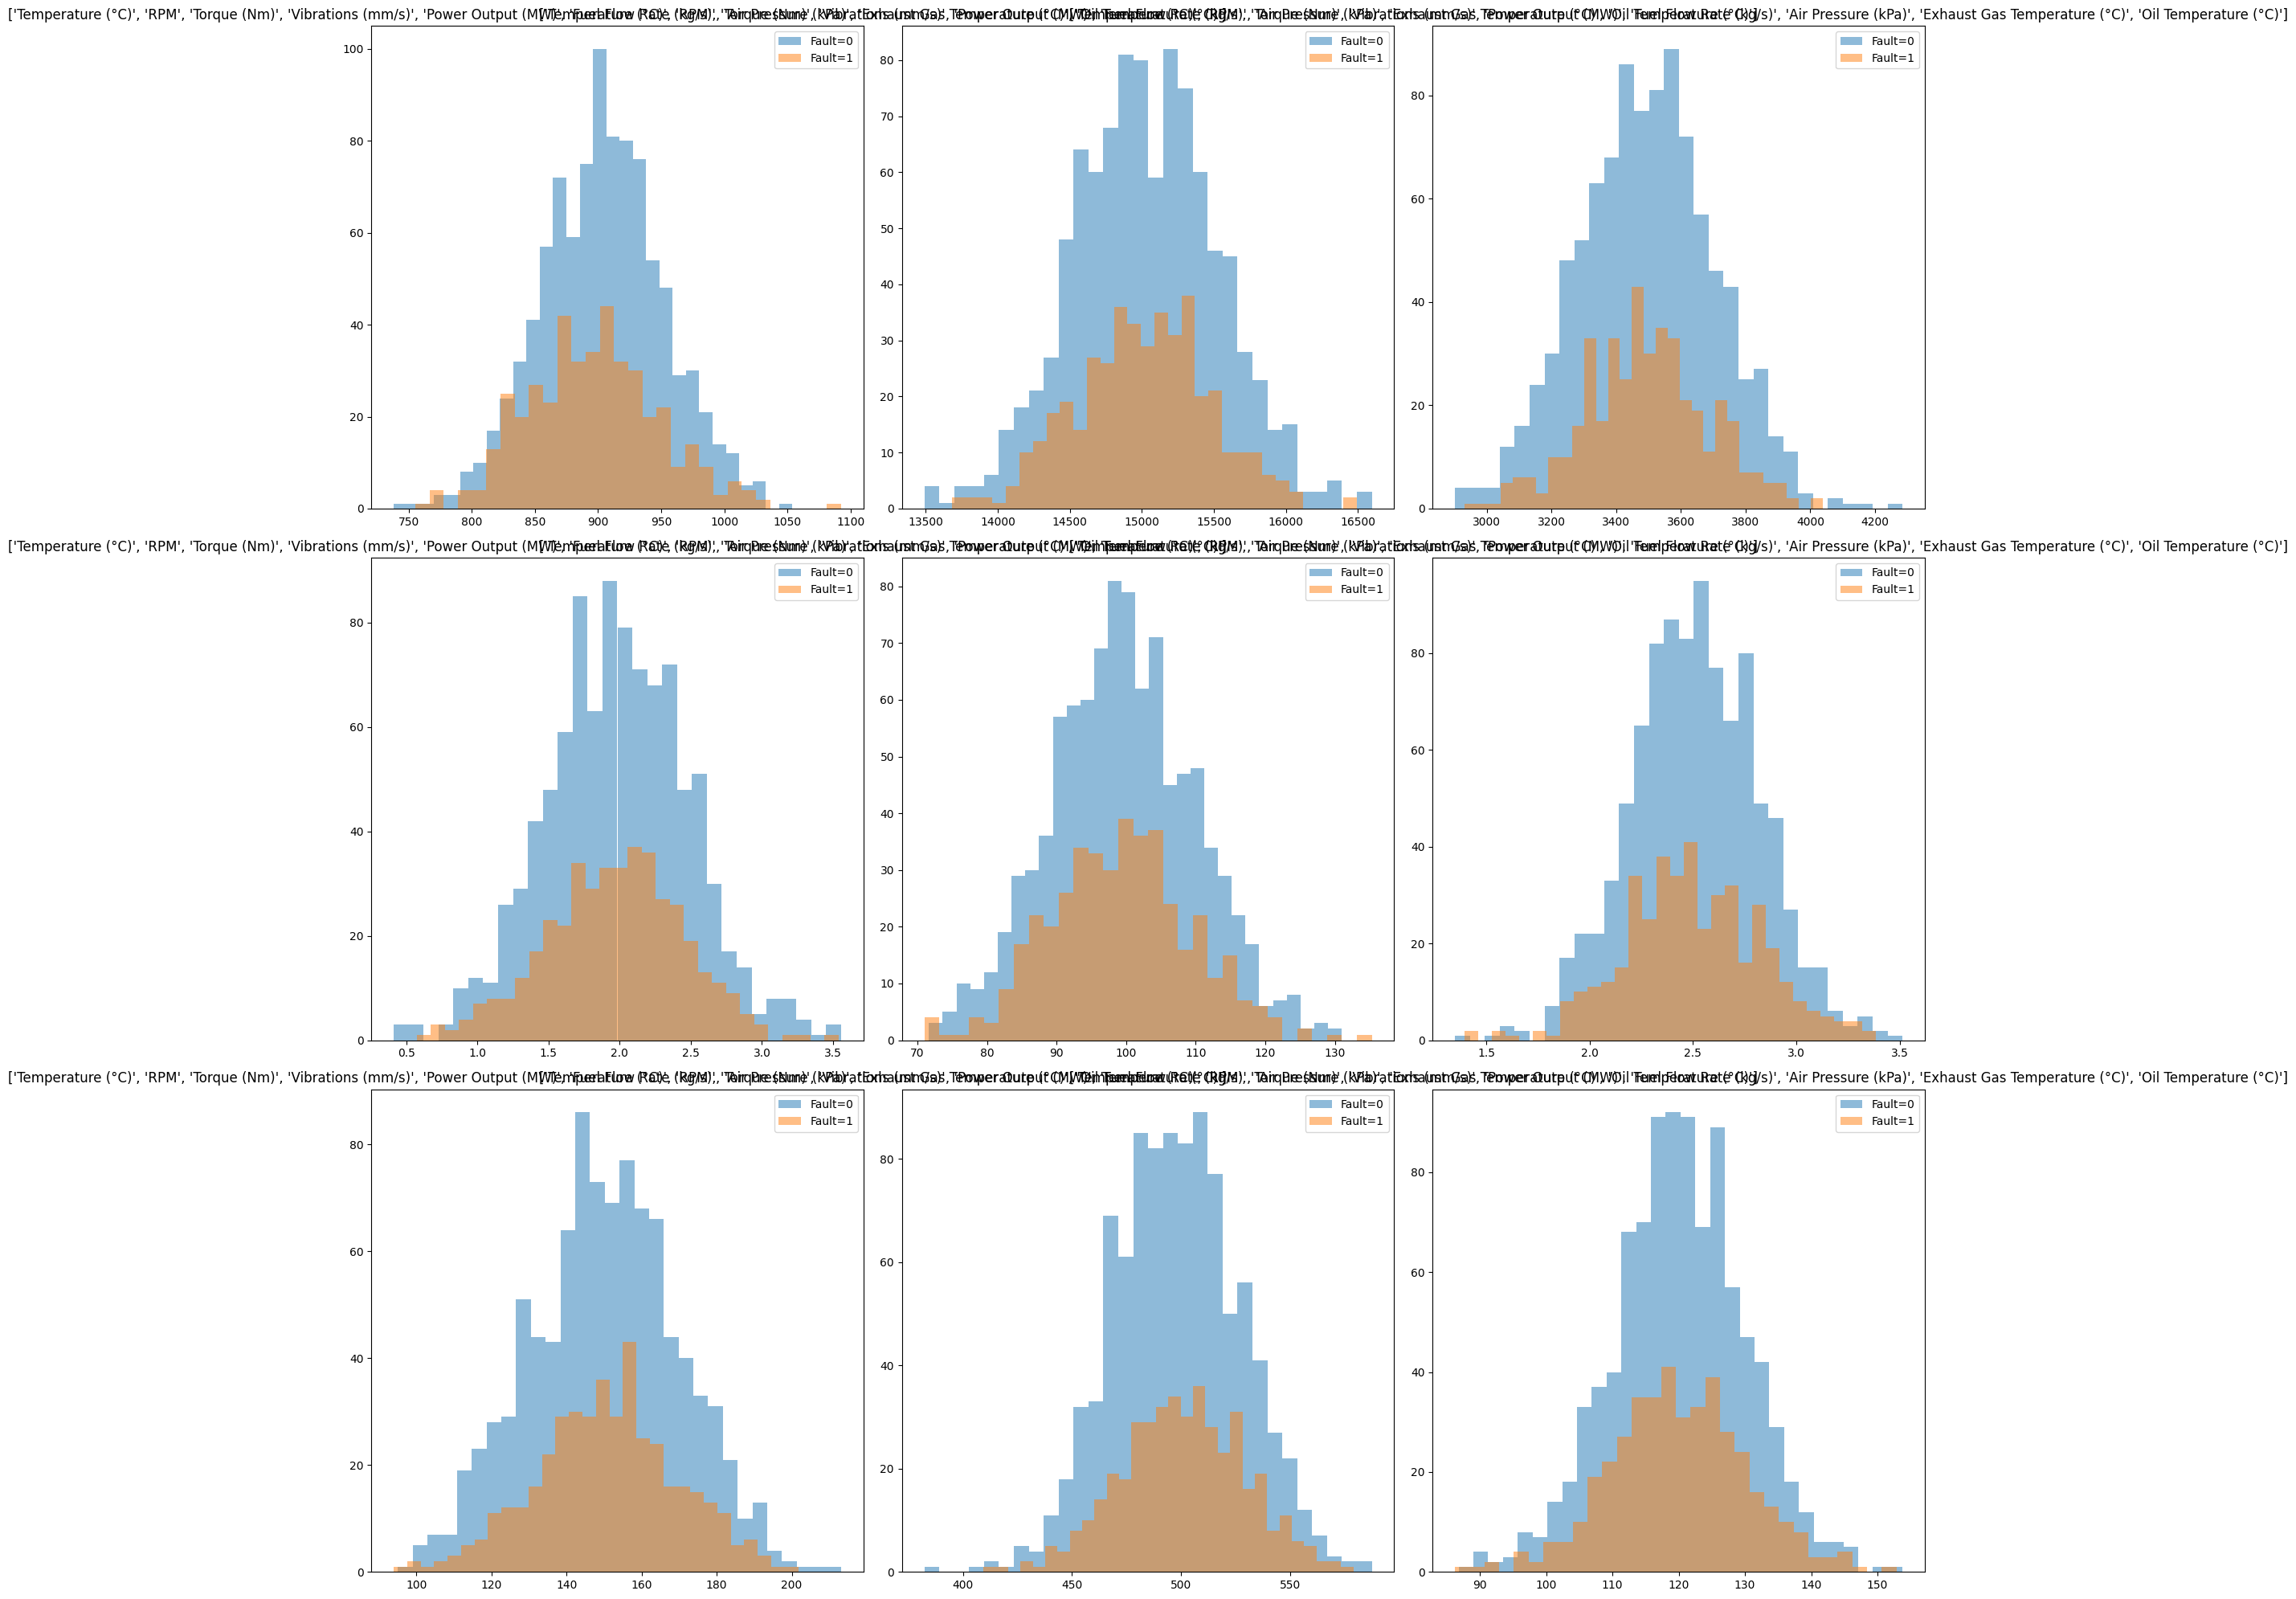

In [8]:
#Histograms
fig, axes = plt.subplots(3, 3, figsize=(20,20))
axes = axes.flatten()
for i, feature in enumerate(features):
    for fault_class in [0, 1]:
        subset = df[df['Fault'] == fault_class][feature]
        axes[i].hist(subset, bins=30, alpha=0.5, label=f'Fault={fault_class}')
        axes[i].set_title(features)
        axes[i].legend()

plt.tight_layout()
plt.show()

In [9]:
#Data preprocessing & Handle outliers
def detect_outliers_iqr(df, features):
    outlier_info = {}
    for feature in features:
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        outlier_info[feature] = len(outliers)
    return outlier_info

outliers = detect_outliers_iqr(df, features)
print("Outlier counts per feature:\n", outliers)

Outlier counts per feature:
 {'Temperature (°C)': 11, 'RPM': 13, 'Torque (Nm)': 11, 'Vibrations (mm/s)': 12, 'Power Output (MW)': 7, 'Fuel Flow Rate (kg/s)': 14, 'Air Pressure (kPa)': 6, 'Exhaust Gas Temperature (°C)': 11, 'Oil Temperature (°C)': 16}


In [10]:
# Separate features and target
X = df.drop('Fault', axis=1)
y = df['Fault']

# Split data (stratify to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Train class distribution:\n{y_train.value_counts(normalize=True)}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier interpretation
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

Train shape: (1108, 9)
Test shape: (278, 9)
Train class distribution:
Fault
0    0.693141
1    0.306859
Name: proportion, dtype: float64


In [11]:
#Exploratory Feature Engineering
# Domain-specific interaction features
X_train_engineered = X_train.copy()
X_test_engineered = X_test.copy()

# Thermal efficiency proxy (Power / Fuel Flow)
X_train_engineered['Thermal_Efficiency'] = X_train['Power Output (MW)'] / X_train['Fuel Flow Rate (kg/s)']
X_test_engineered['Thermal_Efficiency'] = X_test['Power Output (MW)'] / X_test['Fuel Flow Rate (kg/s)']

# Temperature differentials
X_train_engineered['Temp_Diff'] = X_train['Exhaust Gas Temperature (°C)'] - X_train['Temperature (°C)']
X_test_engineered['Temp_Diff'] = X_test['Exhaust Gas Temperature (°C)'] - X_test['Temperature (°C)']

# Stress factor (Torque * RPM)
X_train_engineered['Stress_Factor'] = X_train['Torque (Nm)'] * X_train['RPM'] / 1e6
X_test_engineered['Stress_Factor'] = X_test['Torque (Nm)'] * X_test['RPM'] / 1e6

# Vibration severity
X_train_engineered['Vib_Severity'] = X_train['Vibrations (mm/s)'] * X_train['RPM'] / 1e4
X_test_engineered['Vib_Severity'] = X_test['Vibrations (mm/s)'] * X_test['RPM'] / 1e4

# Oil temperature relative to exhaust
X_train_engineered['Oil_Exhaust_Ratio'] = X_train['Oil Temperature (°C)'] / X_train['Exhaust Gas Temperature (°C)']
X_test_engineered['Oil_Exhaust_Ratio'] = X_test['Oil Temperature (°C)'] / X_test['Exhaust Gas Temperature (°C)']

print("New features added!")
print(X_train_engineered.columns.tolist())

New features added!
['Temperature (°C)', 'RPM', 'Torque (Nm)', 'Vibrations (mm/s)', 'Power Output (MW)', 'Fuel Flow Rate (kg/s)', 'Air Pressure (kPa)', 'Exhaust Gas Temperature (°C)', 'Oil Temperature (°C)', 'Thermal_Efficiency', 'Temp_Diff', 'Stress_Factor', 'Vib_Severity', 'Oil_Exhaust_Ratio']


In [12]:
#Scale Engineered Features
#Re-scale after feature engineering
scaler_engineered = StandardScaler()
X_train_final = scaler_engineered.fit_transform(X_train_engineered)
X_test_final = scaler_engineered.transform(X_test_engineered)
X_test_final = scaler_engineered.transform(X_test_engineered)


Logistic Regression Results
Accuracy:  0.6906
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.5081


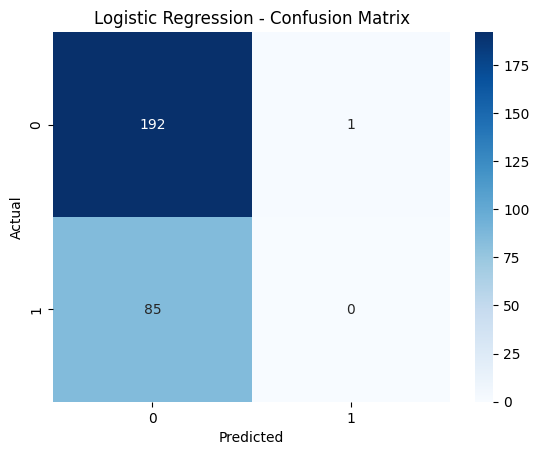


Random Forest Results
Accuracy:  0.6799
Precision: 0.3000
Recall:    0.0353
F1-Score:  0.0632
ROC-AUC:   0.4837


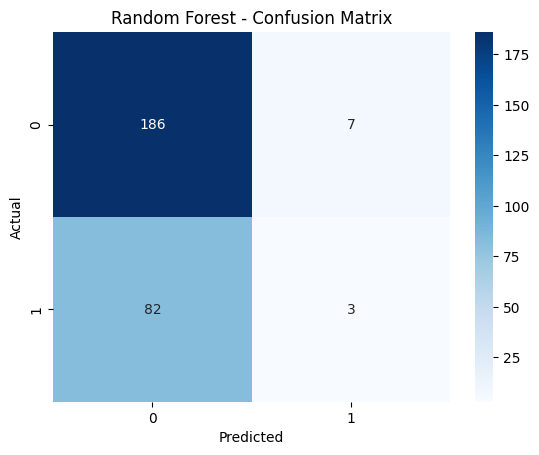


Gradient Boosting Results
Accuracy:  0.6906
Precision: 0.4444
Recall:    0.0471
F1-Score:  0.0851
ROC-AUC:   0.4949


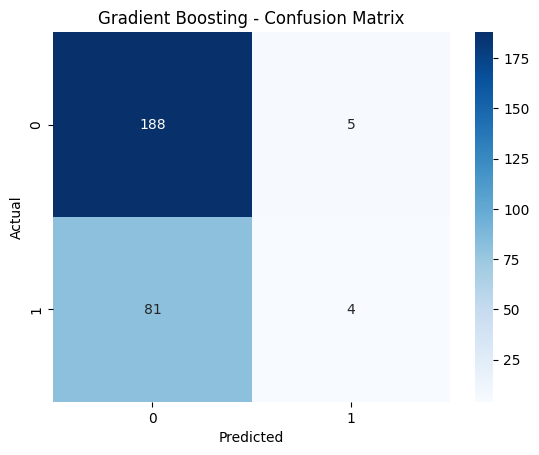


SVM Results
Accuracy:  0.6942
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000
ROC-AUC:   0.4970


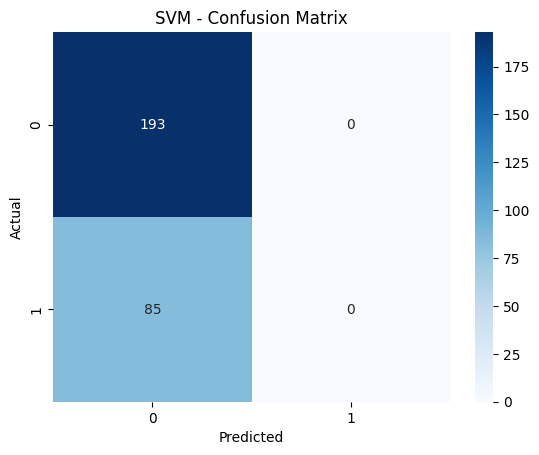

In [13]:
#Model development
#baseline model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    print(f"\n{'='*50}")
    print(f"{model_name} Results")
    print(f"{'='*50}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
    
    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC-AUC:   {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    return model

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

# Train and evaluate each model
trained_models = {}
for name, model in models.items():
    trained_models[name] = evaluate_model(model, X_train_final, X_test_final, 
                                          y_train, y_test, name)

In [14]:
#Cross-Validation
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_final, y_train, cv=cv, scoring='f1')
    print(f"{name:25} CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

Logistic Regression       CV F1-Score: 0.0058 (+/- 0.0232)
Random Forest             CV F1-Score: 0.0657 (+/- 0.0863)
Gradient Boosting         CV F1-Score: 0.0876 (+/- 0.0514)
SVM                       CV F1-Score: 0.0058 (+/- 0.0232)


In [15]:
#Hyperparameter Tuning
# Random Forest hyperparameter grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train_final, y_train)
print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF F1-Score: {rf_grid.best_score_:.4f}")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best RF F1-Score: 0.2080


In [ ]:
#Gradient  Boosting hyperparameter grid
gb_param_grid = { 
    'n_estimator': [100,200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3,5,7],
    'min_samples_split': [2, 5],
    'subsample': [0.8, 1.0]
}

gb_grid = GridSearchCV (
    GradientBoostingClassifier(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train_final, y_train)
print(f"Best GB Parameters: {gb_grid.best_params_}")
print(f"Best GB F1-Score: {gb_grid.best_score_:.4f}")

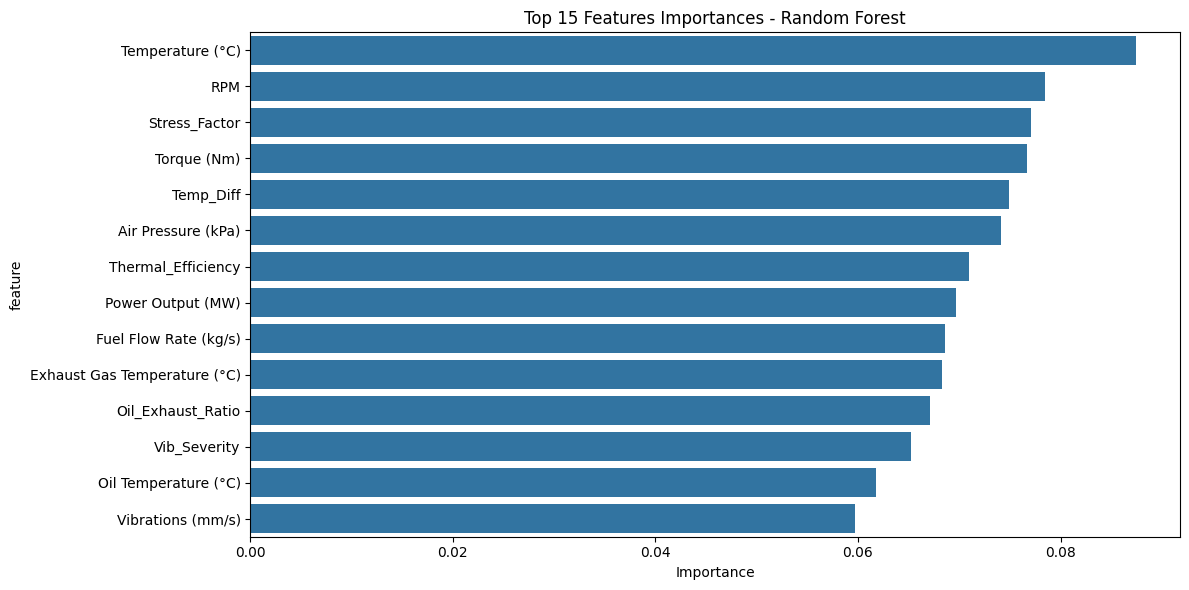

                         feature  importance
0               Temperature (°C)    0.087427
1                            RPM    0.078497
11                 Stress_Factor    0.077046
2                    Torque (Nm)    0.076691
10                     Temp_Diff    0.074883
6             Air Pressure (kPa)    0.074117
9             Thermal_Efficiency    0.070947
4              Power Output (MW)    0.069685
5          Fuel Flow Rate (kg/s)    0.068573
7   Exhaust Gas Temperature (°C)    0.068272
13             Oil_Exhaust_Ratio    0.067084
12                  Vib_Severity    0.065234
8           Oil Temperature (°C)    0.061826
3              Vibrations (mm/s)    0.059719


In [18]:
#Feature Importance Analysis
#Get best Random Forest model
best_rf = rf_grid.best_estimator_
#Feature importance
feature_importance = pd.DataFrame({ 'feature': X_train_engineered.columns,'importance':
                                    best_rf.feature_importances_}).sort_values('importance', ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature',data=feature_importance.head(15))
plt.title('Top 15 Features Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(feature_importance.head(15))

In [ ]:
# First, install the shap library
!pip install shap

# Then run your original code
#Model Interpretation with SHAP
import shap

# SHAP explainer for best model
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_train_final[:100])  # First 100 samples

# Summary plot
shap.summary_plot(shap_values[1], X_train_final[:100], feature_names=X_train_engineered.columns)

# Bar plot
shap.summary_plot(shap_values[1], X_train_final[:100], feature_names=X_train_engineered.columns, plot_type="bar")

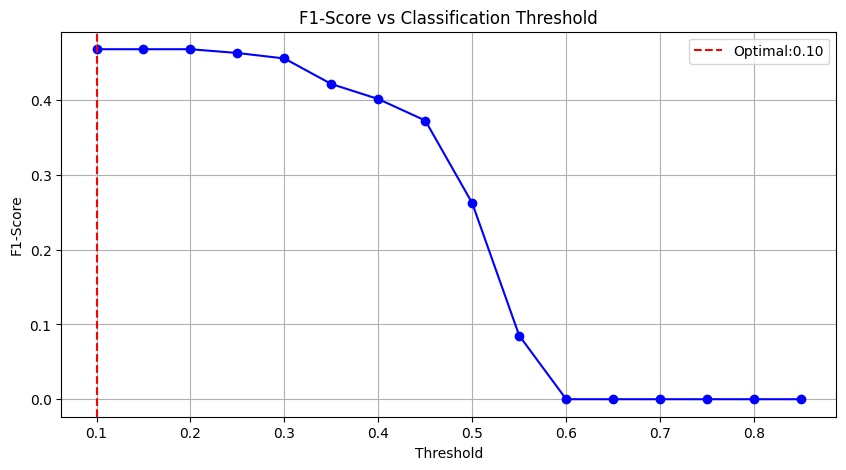

Optimal threshold:0.10
Best F1-Score at optimal threshold:0.4683


In [23]:
#Threshold Optimization
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

# Get probabilities - this is the key fix
# Random Forest returns class labels by default, not probabilities
y_proba = best_rf.predict_proba(X_test_final)[:, 1]  # Use predict_proba instead of predict

# Find optimal Threshold
thresholds = np.arange(0.1, 0.9, 0.05)  # Fixed typo: arrange -> arange
f1_scores = []
for threshold in thresholds:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# Fix indentation - these were inside the loop but should be outside
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, 'bo-')
plt.axvline(x=optimal_threshold, color='r',
linestyle='--', label=f'Optimal:{optimal_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Classification Threshold')
plt.legend()
plt.grid(True)
plt.show()

print(f"Optimal threshold:{optimal_threshold:.2f}")
print(f"Best F1-Score at optimal threshold:{max(f1_scores):.4f}")


FINAL MODEL PERFORMANCE (Random Forest with Optimal Threshold)
Accuracy:  0.3058
Precision: 0.3058
Recall:    1.0000
F1-Score:  0.4683
ROC-AUC:   0.5353
Optimal Threshold: 0.10


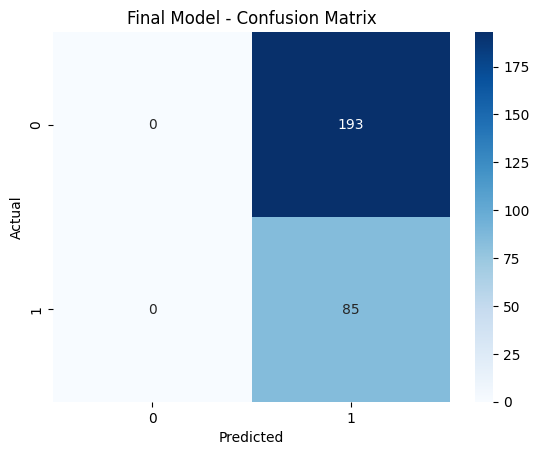


Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00       193
       Fault       0.31      1.00      0.47        85

    accuracy                           0.31       278
   macro avg       0.15      0.50      0.23       278
weighted avg       0.09      0.31      0.14       278



In [25]:
#final Model Evaluation
# Final predictions with optimal threshold
y_pred_optimal = (y_proba >= optimal_threshold).astype(int)

print("="*60)
print("FINAL MODEL PERFORMANCE (Random Forest with Optimal Threshold)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_optimal):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"Optimal Threshold: {optimal_threshold:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimal)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Final Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=['Normal', 'Fault']))

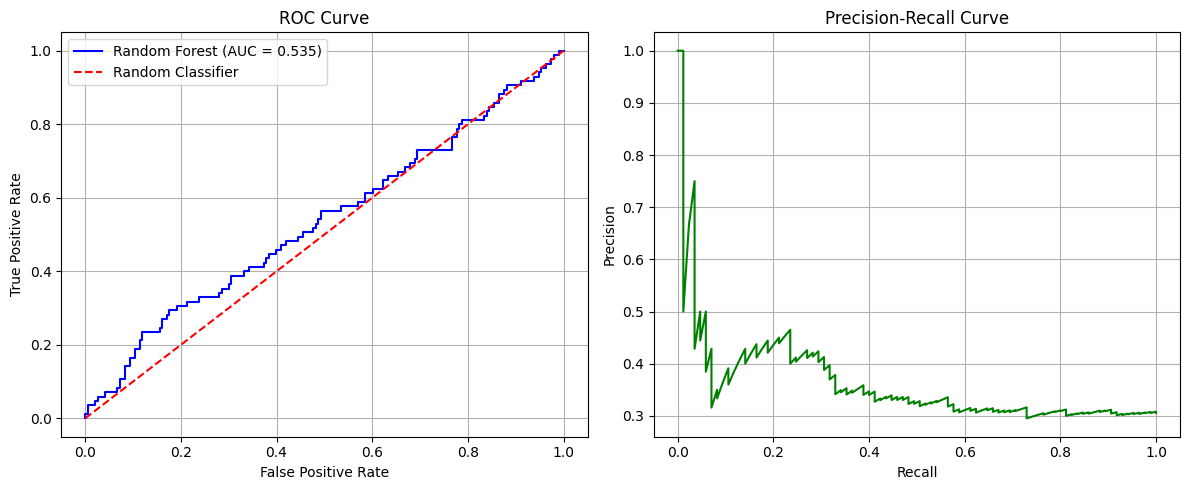

In [28]:
#ROC & Precision-Recall Curves
#ROC Curves
fpr, tpr,_ = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, 'b-', label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)

#Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, 'g-')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

plt.tight_layout()
plt.show()

In [31]:
#Save Model for Production(Pickle:pkl)
import joblib
#Save final model and preprocessing objects
joblib.dump(best_rf, 'gas_turbine_fault_model.pkl')
joblib.dump(scaler_engineered, 'feature_scaler.pkl')
joblib.dump(optimal_threshold, 'optimal_threshold.pkl')
joblib.dump(feature_importance, 'feature_importance.pkl')

print("Models saved successfully!")

#Save feature list for inference
feature_columns = X_train_engineered.columns.tolist()
joblib.dump(feature_columns,'feature_columns.pkl')

Models saved successfully!


['feature_columns.pkl']

In [32]:
#Prodcution Inference Function
def predict_fault(input_data, model_path='gas_turbine_fault_model.pkl', 
                  scaler_path='feature_scaler.pkl', 
                  threshold_path='optimal_threshold.pkl',
                  feature_cols_path='feature_columns.pkl'):
    """
    Predict fault status for new sensor readings
    
    Parameters:
    - input_data: dict or DataFrame with raw sensor values
    - Returns: prediction (0=Normal, 1=Fault) and probability
    """
    # Load artifacts
    model = joblib.load(model_path)
    scaler = joblib.load(scaler_path)
    threshold = joblib.load(threshold_path)
    feature_cols = joblib.load(feature_cols_path)
    
    # Convert to DataFrame if dict
    if isinstance(input_data, dict):
        input_df = pd.DataFrame([input_data])
    else:
        input_df = input_data.copy()
    
    # Feature engineering
    input_df['Thermal_Efficiency'] = input_df['Power Output (MW)'] / input_df['Fuel Flow Rate (kg/s)']
    input_df['Temp_Diff'] = input_df['Exhaust Gas Temperature (°C)'] - input_df['Temperature (°C)']
    input_df['Stress_Factor'] = input_df['Torque (Nm)'] * input_df['RPM'] / 1e6
    input_df['Vib_Severity'] = input_df['Vibrations (mm/s)'] * input_df['RPM'] / 1e4
    input_df['Oil_Exhaust_Ratio'] = input_df['Oil Temperature (°C)'] / input_df['Exhaust Gas Temperature (°C)']
    
    # Ensure correct column order
    input_df = input_df[feature_cols]
    
    # Scale
    input_scaled = scaler.transform(input_df)
    
    # Predict
    proba = model.predict_proba(input_scaled)[0, 1]
    prediction = 1 if proba >= threshold else 0
    
    return {
        'prediction': prediction,
        'fault_probability': proba,
        'status': 'FAULT DETECTED' if prediction == 1 else 'NORMAL OPERATION'
    }

# Example usage
sample = {
    'Temperature (°C)': 900,
    'RPM': 15000,
    'Torque (Nm)': 3500,
    'Vibrations (mm/s)': 2.0,
    'Power Output (MW)': 100,
    'Fuel Flow Rate (kg/s)': 2.5,
    'Air Pressure (kPa)': 150,
    'Exhaust Gas Temperature (°C)': 500,
    'Oil Temperature (°C)': 120
}

result = predict_fault(sample)
print(f"Prediction: {result['prediction']}")
print(f"Fault Probability: {result['fault_probability']:.4f}")
print(f"Status: {result['status']}")

Prediction: 1
Fault Probability: 0.4475
Status: FAULT DETECTED


In [33]:
#Temopral features
#Advanced Time-Series Analysis
# Add lag features and rolling statistics
def create_temporal_features(df, window=5):
    df_temp = df.copy()
    
    # Rolling means for critical parameters
    rolling_features = ['Temperature (°C)', 'Vibrations (mm/s)', 
                       'Exhaust Gas Temperature (°C)', 'Oil Temperature (°C)']
    
    for feature in rolling_features:
        df_temp[f'{feature}_rolling_mean_{window}'] = df_temp[feature].rolling(window).mean()
        df_temp[f'{feature}_rolling_std_{window}'] = df_temp[feature].rolling(window).std()
        df_temp[f'{feature}_rate_change'] = df_temp[feature].pct_change()
    
    # Drop NaN values from rolling calculations
    df_temp = df_temp.dropna()
    
    return df_temp

# Apply to your data (assuming order matters)
df_with_temporal = create_temporal_features(df)
print(f"Added temporal features: {df_with_temporal.shape[1] - df.shape[1]} new columns")

Added temporal features: 12 new columns
